#### Note:

1. Формализовать текущий пайплайн в LangChain (Redis + ChromaDB);
2. Модифицировать его проверками на входе и выходе (необходимо избежать ситуации когда он отвечает абсруд);
3. Модифицировать его циклом на попытку ответа в случае неудачи.
4. Обязательно сделать его человеком при ответе пользователю (возможен routing на human-native answer);
5. Исследуем GPT-oss?

Help docs:

https://yandex.cloud/ru/docs/ai-studio/concepts/generation/models#sdk_1

# Import Libs

In [1]:
import json
from typing import TypedDict, List, Optional
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
import numpy as np
import asyncio
from abc import ABC

# Работаем с секретами
from dotenv import load_dotenv
import os

from functools import lru_cache
# Работаем с Redis \ ChromaDB

load_dotenv("../../.env")

from UnionChatBot.utils.ChatHistoryManager import ChatHistoryManager
from UnionChatBot.utils.ChromaAdapter import ChromaAdapter
from UnionChatBot.utils.RedisAdapters import SemanticRedisCache

# Define general args

In [2]:
openai_api_key=os.getenv("API_KEY")
FOLDER_ID = os.getenv("FOLDER_ID")
openai_api_base="https://llm.api.cloud.yandex.net/v1"
model=f"gpt://{FOLDER_ID}/gpt-oss-120b/latest"

In [3]:
class AgentState(TypedDict):
    embedding_input: np.ndarray
    user_id: str
    collection_name: str
    user_input: str
    model_output: str
    error: str
    is_valid_input: bool
    is_cached: bool
    is_valid_output: bool
    tasks: List[str]
    tasks_results: List[str]

# Define Two LLM Types

In [4]:
llm_yandex_light = ChatOpenAI(
    model=f"gpt://{FOLDER_ID}/yandexgpt-lite",
    temperature=0,
    openai_api_base=openai_api_base,
    openai_api_key=openai_api_key, 
)

In [5]:
llm_gpt = ChatOpenAI(
    model=f"gpt://{FOLDER_ID}/gpt-oss-120b/latest",
    temperature=0.2,
    openai_api_base=openai_api_base,
    openai_api_key=openai_api_key, 
)

# Define Embeder

In [6]:
import os
from typing import Any

import numpy as np
import requests
import time

from chromadb import Documents, EmbeddingFunction, Embeddings


class MyEmbeddingFunction(EmbeddingFunction):
    api_url = os.getenv(
        "EMBEDDING_API",
        "https://llm.api.cloud.yandex.net:443/foundationModels/v1/textEmbedding",
    )
    folder_id = os.getenv("FOLDER_ID", None)
    iam_token = os.getenv("API_KEY", None)
    time_sleep = float(os.getenv("TIME_SLEEP_RATE_EMBEDDER", 0.01))

    def __init__(
        self,
        doc_model_uri: str = None,
        query_model_uri: str = None,
        text_type: str = None,
        *args: Any,
        **kwargs: Any,
    ):
        """
        Initialize the embedding function with Yandex GPT API credentials.

        Args:
            doc_model_uri: Model URI for document embeddings
            query_model_uri: Model URI for query embeddings
            time_sleep: time between each query to yandex api.
        """
        super().__init__(*args, **kwargs)
        self.headers = {
            "Content-Type": "application/json",
            "Authorization": f"Bearer {self.iam_token}",
            "x-folder-id": self.folder_id,
        }
        # set default text type doc if not provided
        self.text_type = text_type or "doc"

        # Set default model URIs if not provided
        self.doc_model_uri = (
            doc_model_uri or f"emb://{self.folder_id}/text-search-doc/latest"
        )
        self.query_model_uri = (
            query_model_uri or f"emb://{self.folder_id}/text-search-query/latest"
        )

    @lru_cache(maxsize=128)
    def _get_single_embedding(self, text: str) -> np.ndarray:
        """
        Get embedding for a single text.

        Args:
            text: Input text to embed
            text_type: "doc" or "query"

        Returns:
            numpy.ndarray: Embedding vector
        """
        model_uri = (
            self.doc_model_uri if self.text_type == "doc" else self.query_model_uri
        )

        data = {"modelUri": model_uri, "text": text}
        time.sleep(self.time_sleep)
        response = requests.post(self.api_url, json=data, headers=self.headers)
        response.raise_for_status()

        return np.array(response.json()["embedding"])

    def __call__(self, input: Documents) -> Embeddings:
        if isinstance(input, str):
            input = [input]

        embeddings = []
        for text in input:
            embedding = self._get_single_embedding(text)
            embeddings.append(embedding)
        return np.array(embeddings)


# Define Main Agentic Logic

In [7]:
class AgentUtils(ABC):
    """ Стандартные возможности агента из коробки
    """
    @staticmethod
    def _load_prompt(path: str, how: str = "local") -> str:
        """ Читаем промпты для работы бота.

        Args:
            path: путь до файла;
            how: где хранится файл;

        Return:
            Текст промпта.
        """
        if how == "local":
            with open(path, "r", encoding="utf-8") as f:
                return f.read()
        elif how == "s3":
            with boto3.client('s3') as s3:
                bucket = s3_params["bucket"]
                key = s3_params["key"]
                obj = s3.get_object(Bucket=bucket, Key=key)
                return obj['Body'].read().decode('utf-8')
        else:
            raise NotImplementedError(f"Unknown source: {how}")
            
    def _get_user_history_text_sync(self, user_id: str) -> str:
        """Синхронно получает историю диалога пользователя"""
        try:
            history = self.chat_manager.get_user_history(user_id=user_id)
            return history if history else "История диалога отсутствует."
        except Exception as e:
            # logger.error(f"Error getting user history: {e}")
            return "История диалога недоступна."
    
    def _format_rag_documents(self, data: dict) -> str:
        """Форматирует документы из RAG в читаемый вид."""
        documents = data.get("documents", [])
        metadatas = data.get("metadatas", [])
        
        if not documents:
            return "<RAG>Документы для справки отсутствуют</RAG>"
        
        formatted_docs = []
        
        for idx, (doc_text, metadata) in enumerate(zip(documents, metadatas), 1):
            # Форматируем каждый документ
            formatted_doc = self._format_single_document(idx, doc_text, metadata)
            formatted_docs.append(formatted_doc)
        
        rag_content = "\n\n".join(formatted_docs)
        return rag_content
    
    def _format_single_document(self, index: int, doc_text: str, metadata: dict) -> str:
        """Форматирует один документ с метаданными."""
        # Очищаем и обрезаем текст документа
        clean_text = doc_text.strip()
        
        # Извлекаем информацию из метаданных
        source = metadata.get('source', 'Неизвестный источник')
        document_type = metadata.get('type', 'Документ')
        section = metadata.get('section', '')
        page = metadata.get('page', '')
        
        # Форматируем источник
        source_info = []
        if source and source != 'Неизвестный источник':
            source_info.append(f"Источник: {source}")
        if document_type and document_type != 'Документ':
            source_info.append(f"Тип: {document_type}")
        if section:
            source_info.append(f"Раздел: {section}")
        if page:
            source_info.append(f"Страница: {page}")
        
        source_line = " | ".join(source_info) if source_info else "Источник не указан"
        
        return f"""Документ #{index}:
    {clean_text}
    
    [{source_line}]"""

In [8]:
class ProfkomAgent(AgentUtils):
    invalid_user_input: str = "Ваш текст не прошел проверку фильтра и не может быть обработан."
    
    def __init__(self,
                 llm_easy,
                 llm_hard,
                 redis_cache: SemanticRedisCache,
                 chat_manager: ChatHistoryManager,
                 chroma_adapter: ChromaAdapter,
                 text_embeder: MyEmbeddingFunction,
                 prompt_dir="../../prompts",
                 s3_info: Optional[dict] = {}):
        self.llm_easy = llm_easy
        self.llm_hard = llm_hard
        self.redis_cache = redis_cache
        self.chat_manager = chat_manager
        self.chroma_adapter = chroma_adapter
        self.text_embeder = text_embeder
        
        self.s3_info = s3_info
        self.prompts = {
            "validate": self._load_prompt(f"{prompt_dir}/filter_prompt.txt", how="local"),
            "decompose": self._load_prompt(f"{prompt_dir}/decompose_question.txt", how="local"),
            "answer_part": self._load_prompt(f"{prompt_dir}/answer_part.txt", how="local"),
            "collect_final": self._load_prompt(f"{prompt_dir}/summary_results.txt", how="local"),
            "determine_collection": self._load_prompt(f"{prompt_dir}/determine_collection.txt", how="local")
        }

    async def check_redis_cache(self, state: AgentState) -> AgentState:
        """Проверяем кэш Redis (асинхронная версия)."""
        state["is_cached"] = False
        # Cоздаем ембединг для входящего запроса
        state["embedding_input"] = await asyncio.to_thread(self.text_embeder,
                                                           state["user_input"])
        # Асинхронно проверяем кэш Redis
        cached = await asyncio.to_thread(
            self.redis_cache.get,
            query_embedding=state["embedding_input"], 
            query=state["user_input"]
        )
        
        if cached:
            # Асинхронно сохраняем в историю
            await asyncio.to_thread(
                self.chat_manager.add_message_to_history,
                state["user_id"],
                cached["response"]
            )
            state["is_cached"] = True
            state["model_output"] = cached["response"]
        
        return state
        
    async def validate_text(self, state: AgentState) -> AgentState:
        """ Проверяем, что текст валидный исходя из логики промпта.

        Arg:
            state: Состояние агента на текущем шаге.

        Return:
            Обновленное состояние агента о том, что это валидный вопрос.
        """
        prompt = ChatPromptTemplate.from_template(self.prompts["validate"])
        chain = prompt | self.llm_easy
        response_obj = await chain.ainvoke({"text": state["user_input"]})
        response = response_obj.content.strip().lower() 

        if "valid" in response:
            state["is_valid_input"] = True
        else:
            state["is_valid_input"] = False
            state["model_output"] = self.invalid_user_input
            state["error"] = response
        return state

    async def _determine_collection_with_llm(self, text: str) -> str:
        """Использует LLM для определения коллекции на основе организации"""
        prompt = ChatPromptTemplate.from_template(self.prompts["determine_collection"])
        chain = prompt | self.llm_hard
        
        response_obj = await chain.ainvoke({"organization": text})
        response = response_obj.content.strip()
        
        # Парсим ответ LLM
        if "<КОЛЛЕКЦИЯ>" in response and "</КОЛЛЕКЦИЯ>" in response:
            start_idx = response.find("<КОЛЛЕКЦИЯ>") + len("<КОЛЛЕКЦИЯ>")
            end_idx = response.find("</КОЛЛЕКЦИЯ>")
            collection = response[start_idx:end_idx].strip()
        else:
            collection = response.strip()
        return collection

    async def decomposer(self, state: AgentState) -> AgentState:
        """Разделяем запрос пользователя на несколько вложенных с учетом истории."""
        # Получаем историю пользователя из базового класса
        user_history = await asyncio.to_thread(
        self._get_user_history_text_sync,  # ← передаем функцию, а не результат
        state["user_id"]                   # ← аргумент отдельно
        )
        
        prompt = ChatPromptTemplate.from_template(self.prompts["decompose"])
        chain = prompt | self.llm_hard

        user_question = state['user_input']
        
        response_obj = await chain.ainvoke({
            "user_question": user_question,
            "user_history": user_history})
        
        try:
            response_text = response_obj.content.strip()
            
            # Извлекаем задачи из блока <ЗАДАЧИ>
            if "<ЗАДАЧИ>" in response_text and "</ЗАДАЧИ>" in response_text:
                start_idx = response_text.find("<ЗАДАЧИ>") + len("<ЗАДАЧИ>")
                end_idx = response_text.find("</ЗАДАЧИ>")
                tasks_text = response_text[start_idx:end_idx].strip()
            else:
                tasks_text = response_text
            
            # Разделяем задачи по <PART>
            if "<PART>" in tasks_text:
                state["tasks"] = [task.strip() for task in tasks_text.split("<PART>") if task.strip()]
            else:
                state["tasks"] = [tasks_text]
                
        except Exception as e:
            state["error"] = f"Decomposition error: {str(e)}"
            state["tasks"] = [user_question]
        
        return state

    async def process_all_tasks(self, state: AgentState, max_concurrent: int = 3) -> AgentState:
        """Обрабатывает все подзадачи параллельно с ограничением количества одновременных запросов"""
        if not state.get("tasks"):
            state["error"] = "No tasks to process"
            state["tasks_results"] = []
            return state

        semaphore = asyncio.Semaphore(max_concurrent)
        prompt = ChatPromptTemplate.from_template(self.prompts["answer_part"])
        chain = prompt | self.llm_hard
        
        
        async def process_single_task(task: str) -> str:
            async with semaphore:
                documents = await asyncio.to_thread(
                    self.chroma_adapter.get_info,  # функция
                    task,                          # query
                    state["collection_name"]       # collection_name
                )
                doc_info = self._format_rag_documents(documents)
                response_obj = await chain.ainvoke({
                    "task_question": task,
                    "additional_documents": doc_info
                })
                return response_obj.content.strip()
        # Узнаем название коллекции исходя из вопроса пользователя
        state["collection_name"] = await self._determine_collection_with_llm(text=state["user_input"][:90])
        
        # Создаем и выполняем все задачи параллельно
        tasks = [asyncio.create_task(process_single_task(task)) for task in state["tasks"]]
        state["tasks_results"] = await asyncio.gather(*tasks, return_exceptions=True)
        
        # Обрабатываем исключения
        state["tasks_results"] = [
            f"Ошибка при обработке: {str(result)}" if isinstance(result, Exception) else result
            for result in state["tasks_results"]
        ]
        
        return state
   

    async def summarize_responses(self, state: AgentState) -> AgentState:
        """Суммаризирует ответы в финальный результат."""
        if not state.get("tasks_results") or not state.get("tasks"):
            state["error"] = "No responses to summarize"
            return state
            
        user_history = await asyncio.to_thread(
            self._get_user_history_text_sync,  # функция
            state["user_id"]                   # аргумент
        )
        prompt = ChatPromptTemplate.from_template(self.prompts["collect_final"])
        chain = prompt | self.llm_hard
        
        # Форматируем ответы для суммаризации
        task_responses_text = "\n\n".join([
            f"Вопрос: {task}\nОтвет: {answer}" 
            for task, answer in zip(state["tasks"], state["tasks_results"])
        ])
        
        original_question = state['user_input']
        
        response_obj = await chain.ainvoke({
            "user_history":user_history,
            "original_question": original_question,
            "task_responses": task_responses_text
        })
        
        state["model_output"] = response_obj.content.strip()
        return state

    async def validate_output(self, state: AgentState) -> AgentState:
        """Проверяем, что финальный ответ модели валиден."""
        prompt = ChatPromptTemplate.from_template(self.prompts["validate"])  # Можно использовать тот же промпт или создать отдельный
        chain = prompt | self.llm_easy
        
        # Проверяем сгенерированный ответ
        response_obj = await chain.ainvoke({"text": state["model_output"]})
        response = response_obj.content.strip().lower()
        
        
        if "valid" not in response:
            # Можно добавить fallback логику здесь
            state["error"] = "Generated response failed validation"
            state["is_valid_output"] = False
        else:
            state["is_valid_output"] = True
        
        return state
    
    async def handle_error(self, state: AgentState) -> AgentState:
        """Обрабатываем ошибки валидации."""
        state["model_output"] = "Извините, произошла ошибка при генерации ответа. Пожалуйста, попробуйте переформулировать вопрос."
        return state

In [9]:
agent = ProfkomAgent(llm_easy=llm_yandex_light,
                     llm_hard=llm_gpt,
                     redis_cache=SemanticRedisCache(db=0),
                     chat_manager=ChatHistoryManager(),
                     chroma_adapter=ChromaAdapter(text_type="query"),
                     text_embeder=MyEmbeddingFunction(text_type="text")
                    )

/var/folders/c5/y0wp15v13_3dhst59xtgt4ww0000gn/T/ipykernel_29338/954169021.py:36: DeprecationWarning: The class MyEmbeddingFunction does not implement __init__. This will be required in a future version.
  super().__init__(*args, **kwargs)


In [10]:
builder = StateGraph(AgentState, is_async=True)

# Добавляем все узлы
builder.add_node("check_redis_cache", agent.check_redis_cache)
builder.add_node("validate_input", agent.validate_text)
builder.add_node("decomposer", agent.decomposer)
builder.add_node("process_tasks", agent.process_all_tasks)
builder.add_node("summarize_responses", agent.summarize_responses)
builder.add_node("validate_output", agent.validate_output)  # НОВЫЙ узел для валидации ответа

# Устанавливаем начальную точку
builder.set_entry_point("check_redis_cache")

# Маршрутизация после проверки кэша
def route_after_cache(state: AgentState):
    return END if state["is_cached"] else "validate_input"

builder.add_conditional_edges("check_redis_cache", route_after_cache, {
    "validate_input": "validate_input",
    END: END
})

# Маршрутизация после валидации ввода
def route_after_validate_input(state: AgentState):
    return "decomposer" if state["is_valid_input"] else END

builder.add_conditional_edges("validate_input", route_after_validate_input, {
    "decomposer": "decomposer", 
    END: END
})

# Основная цепочка обработки
builder.add_edge("decomposer", "process_tasks")
builder.add_edge("process_tasks", "summarize_responses")
builder.add_edge("summarize_responses", "validate_output")

# Маршрутизация после валидации вывода
def route_after_validate_output(state: AgentState):
    return END if state["is_valid_output"] else "error_handler"

builder.add_conditional_edges("validate_output", route_after_validate_output, {
    END: END,
    "error_handler": "error_handler"
})

# Узел для обработки ошибок (опционально)
builder.add_node("error_handler", agent.handle_error)
builder.add_edge("error_handler", END)

graph = builder.compile()

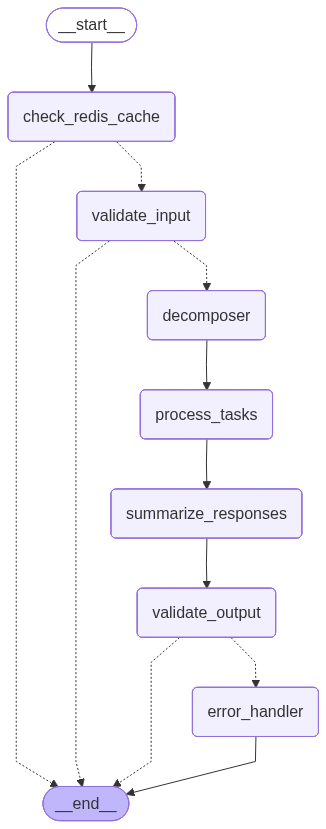

In [19]:
graph

# Text pipeline

In [20]:
user_info="Член профсоюзной организации: ППО Невинномысский Азот"
user_input=f"[{user_info}] | Приветствую! Имеет ли право работодатель вызывать меня в выходной день из-за остановки цеха?"

In [21]:
start_state = AgentState(
    user_id="141",
    user_input=user_input
)

In [22]:
result = await graph.ainvoke(start_state)

In [23]:
result

{'embedding_input': [array([ 2.76336670e-02, -8.69750977e-04, -4.71801758e-02, -3.04260254e-02,
         -2.07366943e-02, -5.50537109e-02,  1.72271729e-02, -4.02221680e-02,
          5.29174805e-02, -5.73425293e-02,  4.18090820e-02, -7.57446289e-02,
         -4.68444824e-02, -3.94821167e-03,  4.68750000e-02,  7.66372681e-03,
          7.37304688e-02, -4.29992676e-02, -7.28759766e-02, -2.27813721e-02,
         -4.88586426e-02,  8.70971680e-02,  8.59375000e-02, -6.19201660e-02,
         -8.61816406e-02, -2.12402344e-02,  5.68847656e-02, -2.67181396e-02,
          5.69763184e-02, -7.94677734e-02,  1.03149414e-01,  3.17993164e-02,
         -3.54614258e-02, -1.10961914e-01,  2.18811035e-02, -4.41894531e-02,
         -7.26699829e-03, -2.89764404e-02,  1.24511719e-02, -5.41076660e-02,
         -1.07055664e-01, -7.51342773e-02, -2.43530273e-02, -1.66320801e-02,
          7.03125000e-02, -7.24411011e-03, -8.49609375e-02, -2.82897949e-02,
          8.28857422e-02,  5.57250977e-02,  6.68945312e-0

In [24]:
len(result["tasks"])

3

In [25]:
result["tasks"]

['Имеет ли работодатель право вызывать сотрудника в выходной день из‑за остановки цеха?',
 'Какая компенсация полагается, если сотрудник согласился выйти в выходной день?',
 'Какие действия может предпринять работник, если он отказывается выйти в выходной день?']

In [26]:
print(result["model_output"])

1. Работодатель не может просто так заставить вас выйти в выходной день без вашего согласия.  
2. Если он хочет изменить ваш график, он обязан предупредить вас письменно минимум за 2 месяца.  
3. Вы можете согласиться выйти — тогда за эту работу вам полагается один свободный день (отгул) в обычном размере.  
4. Отгул нужно взять в течение года с даты, когда вы отработали в выходной.  
5. Если вы не согласны выйти, скажите работодателю, что без вашего согласия работа в выходной невозможна.  
6. Потребуйте оформить ваш отказ письменно, чтобы было доказательство.  
7. При отказе работодатель не имеет права удерживать вашу зарплату или штрафовать вас.  
8. Обратитесь к представителю профсоюза — он поможет оформить ваш отказ и отстоять право на отгул.  
9. Если работодатель всё‑равно настаивает, подайте жалобу в трудовую инспекцию или в суд.  
10. Сохраняйте все документы (письма, справки, заявления) – они понадобятся при защите ваших прав.


## Проверяем простой текст

In [27]:
user_info="Член профсоюзной организации: ППО Невинномысский Азот"
user_input=f"{user_info}] | Какой коллективный договор действует на предприятии? Имеет ли право работодатель изменить его самостоятельно?"

In [28]:
start_state = AgentState(
    user_id="141",
    user_input=user_input
)

In [29]:
result = await graph.ainvoke(start_state)

In [30]:
print(result["model_output"])

На предприятии действует коллективный договор, который вступил в силу 1 января 2024 года и будет действовать до 31 декабря 2026 года – его копию можно взять у секретаря профкома. Работодатель не может менять условия договора сам, без вашего согласия. Если он хочет что‑то изменить, он должен написать письменное предложение в постоянную комиссию по коллективным переговорам. В течение 14 дней комиссия собирает обе стороны, обсуждает предложенные изменения и принимает решение. Если предложенные изменения ухудшают ваши условия (например, снижают зарплату или соцльготы), их нужно ещё утвердить на конференции трудового коллектива. Поэтому, если вам пришло уведомление о «изменениях», сразу спросите у профкома, была ли проведена комиссия и конференция. Если этих шагов не было, требуйте, чтобы их провели, иначе изменения не имеют силы. При любых сомнениях сохраняйте копию письма работодателя и обращайтесь к представителю профсоюза за помощью.


In [33]:
result["tasks"]

['Какой коллективный договор действует на предприятии ППО Невинномысский Азот?',
 'Имеет ли работодатель право самостоятельно изменить действующий коллективный договор?',
 'Каким образом могут вноситься изменения в коллективный договор согласно законодательству?']

In [34]:
result

{'embedding_input': [array([ 0.02218628, -0.04046631, -0.03100586, -0.04321289, -0.02449036,
         -0.0668335 ,  0.01686096, -0.0340271 ,  0.04492188,  0.0144577 ,
         -0.00893402, -0.02870178, -0.12493896,  0.02003479,  0.00615311,
         -0.01490021,  0.0682373 , -0.03018188, -0.05725098, -0.00314522,
         -0.03689575,  0.02503967,  0.01060486, -0.0447998 , -0.04257202,
         -0.04971313,  0.06311035, -0.04730225,  0.08544922, -0.06051636,
          0.10601807,  0.0166626 , -0.0177002 , -0.05575562, -0.02796936,
          0.04510498, -0.00317192, -0.05831909,  0.08300781, -0.01968384,
         -0.10699463, -0.08911133, -0.12158203, -0.01649475,  0.03918457,
          0.01072693, -0.0803833 , -0.05990601,  0.1005249 ,  0.05276489,
          0.03820801,  0.07757568, -0.0411377 ,  0.0647583 , -0.00017655,
          0.02397156, -0.06140137, -0.04351807,  0.00693893, -0.03649902,
          0.03610229, -0.0401001 , -0.05444336,  0.0418396 , -0.02442932,
          0.0597839

In [35]:
user_info="Член профсоюзной организации: ППО Невинномысский Азот"
user_input=f"{user_info}] | А к кому можно обратиться в профкоме для подачи жалобу на работадателя в трудовую инспекцию?"

In [36]:
start_state = AgentState(
    user_id="141",
    user_input=user_input
)

In [37]:
result = await graph.ainvoke(start_state)

In [38]:
print(result["model_output"])

1. Придите в профком к секретарю – Эльвире Аршаковне (или к заместителю, если секретаря нет).  
2. Если в вашем цехе есть табельщик, сначала покажите ему проблему – он тоже принимает жалобы.  
3. Напишите простое заявление: укажите своё ФИО, должность, дату и суть нарушения работодателя.  
4. Приложите копии трудового договора, табеля‑журнала, справки о зарплате и любые бумаги, подтверждающие факт (акты, переписку, показания свидетелей).  
5. Отдайте заявление и копии секретарю – он передаст их в комиссию по трудовым спорам профкома.  
6. Комиссия оформит ваше заявление в виде официального письма и в течение 14 дней отправит его в территориальную трудовую инспекцию.  
7. Профком сохраняет у себя копию письма и выдает вам расписку о получении документов.  
8. После отправки вам сообщат дату и номер отправления, а также когда ждать ответ от инспекции.  
9. Если инспекция запросит дополнительные сведения, профком поможет собрать их и передать дальше.  
10. Вы будете проинформированы о рез

In [41]:
result["tasks"]

['К кому в профкоме ППО Невинномысский Азот следует обратиться для подачи жалобы на работодателя в трудовую инспекцию?',
 'Какова процедура подачи жалобы через профком в трудовую инспекцию?',
 'Какие документы и сведения необходимо подготовить для подачи такой жалобы?']

In [42]:
result

{'embedding_input': [array([ 0.05688477, -0.06524658, -0.06115723, -0.04434204, -0.00850677,
         -0.05102539,  0.00467682, -0.03579712,  0.06665039, -0.02017212,
          0.01327515, -0.09606934, -0.07312012,  0.02966309,  0.00644684,
          0.0045166 ,  0.09234619, -0.0612793 , -0.07867432, -0.02615356,
         -0.02638245,  0.09655762,  0.03692627, -0.0802002 , -0.05331421,
          0.00735855,  0.08666992, -0.06658936,  0.05828857, -0.07177734,
          0.11090088,  0.03887939, -0.05752563, -0.07299805, -0.0166626 ,
          0.07263184, -0.0219574 , -0.02110291,  0.02897644, -0.03265381,
         -0.13806152, -0.10198975, -0.07171631, -0.03491211,  0.01226044,
          0.02687073, -0.13623047, -0.01347351,  0.06161499,  0.08978271,
          0.07543945,  0.09576416, -0.05319214,  0.08258057, -0.0553894 ,
          0.02330017, -0.07299805,  0.00071955, -0.00446701,  0.03915405,
          0.0552063 , -0.06292725, -0.03033447,  0.04049683,  0.01667786,
          0.1273193

In [43]:
user_info="Член профсоюзной организации: ППО Невинномысский Азот"
user_input=f"{user_info}] | Понял! Спасибо! А есть ли новости какие-то последние по профсоюзу?"

In [44]:
start_state = AgentState(
    user_id="141",
    user_input=user_input
)

In [45]:
result = await graph.ainvoke(start_state)

In [46]:
result

{'embedding_input': [array([ 0.0881958 , -0.07214355, -0.02156067, -0.01248169,  0.03384399,
         -0.09429932, -0.02508545, -0.09216309,  0.02137756, -0.03881836,
         -0.02973938, -0.09454346, -0.07421875,  0.00725937,  0.04147339,
         -0.02981567,  0.12731934, -0.09857178, -0.06427002, -0.04827881,
         -0.04428101,  0.04748535, -0.01591492, -0.06234741, -0.08520508,
         -0.04025269,  0.08441162, -0.06982422,  0.09637451, -0.05987549,
          0.09014893,  0.05563354,  0.02653503, -0.01071167, -0.00988007,
          0.04638672, -0.00793457, -0.03038025,  0.05810547, -0.05599976,
         -0.109375  , -0.06365967, -0.07861328, -0.03518677,  0.052948  ,
         -0.00362206, -0.10614014, -0.0447998 ,  0.09710693,  0.05709839,
          0.06228638,  0.04159546, -0.07476807,  0.08551025,  0.02297974,
          0.02366638, -0.02947998, -0.01615906,  0.02752686,  0.02986145,
          0.05197144, -0.10809326, -0.09436035,  0.05737305,  0.02897644,
          0.0924682

In [47]:
print(result["model_output"])

Сейчас в ППО «Невинномысский Азот» одобрены несколько новых льгот для членов профсоюза.  
1️⃣ К официальным праздникам (8 марта, День защитника Отечества, День химика и др.) каждый член получит денежный подарок – размер его определит профком, уточняйте у секретаря.  
2️⃣ Выделено 317 бесплатных путёвок в санаторий‑профилакторий – записаться можно, обратившись к секретарю профкома, указав фамилию, дату рождения и желаемый период отдыха.  
3️⃣ Для детей членов профсоюза подготовлены 67 путёвок с частичной оплатой – для получения уточняйте порядок подачи заявления у того же секретаря.  
4️⃣ Введён порядок единовременной компенсационной помощи до 5 000 руб. в случае тяжёлой болезни, травмы или потери работы – запрос оформляете письменно, приложив справку от врача и копию трудовой книжки.  
5️⃣ Максимальная сумма всех выплат профсоюза в год не превышает 300 000 руб. на одного члена – это ограничение учитывается при одновременном получении нескольких видов помощи.  
Чтобы воспользоваться люб

In [48]:
user_info="Член профсоюзной организации: ППО Невинномысский Азот"
user_input=f"{user_info}] | Расскажи про структуру профсоюза. Как организована работа профсоюза на предприятии? Что такое росхимпрофсоюз?"

In [49]:
start_state = AgentState(
    user_id="141",
    user_input=user_input
)

In [50]:
result = await graph.ainvoke(start_state)

In [54]:
result

{'embedding_input': [array([ 0.04620361, -0.1038208 , -0.05026245,  0.00471878,  0.02096558,
         -0.06100464, -0.02642822, -0.04956055,  0.03875732, -0.01655579,
         -0.021698  , -0.09533691, -0.09661865,  0.00266075,  0.03710938,
         -0.03872681,  0.11859131, -0.05606079, -0.09527588, -0.01394653,
         -0.03768921,  0.09295654,  0.04821777, -0.07287598, -0.06903076,
          0.00305748,  0.05340576, -0.07513428,  0.06890869, -0.03604126,
          0.10223389,  0.06085205, -0.02563477, -0.03038025, -0.00018156,
          0.05953979,  0.02648926, -0.04916382,  0.02401733, -0.0104599 ,
         -0.08831787, -0.0748291 , -0.10412598, -0.04953003,  0.00866699,
          0.03582764, -0.14855957, -0.04470825,  0.05209351,  0.00985718,
          0.01539612,  0.02949524, -0.04489136,  0.08270264,  0.00725174,
         -0.04501343, -0.00978088, -0.04290771,  0.02285767,  0.03475952,
          0.07128906, -0.07019043, -0.07043457,  0.065979  , -0.00345612,
          0.0441894

In [55]:
print(result["model_output"])

1. На заводе самым главным органом является Профсоюзный комитет — профком, который возглавляет председатель.  
2. В профкоме работают цеховые (отраслевые) комитеты – их около 25 и каждый отвечает за свой цех.  
3. При профкоме создаются специальные комиссии: по охране труда, по трудовым спорам и по коллективным переговорам.  
4. Есть касса взаимопомощи, где члены могут брать беспроцентные займы.  
5. Если у вас возник вопрос или проблема, сначала идите к секретарю профкома — он даст форму заявления и подскажет, куда его отнести.  
6. Цеховой комитет собирает ваши обращения и передаёт их в профком, где решают, что делать.  
7. Членам профсоюза разрешено освобождаться от работы для участия в собраниях и выполнения профсоюзных задач.  
8. Чтобы получить займ или финансовую помощь, обратитесь в кассу взаимопомощи — покажите заявление и получите деньги без процентов.  
9. Если нужен совет по конфликту с руководством, пишите в комиссию по трудовым спорам — они помогут подготовить аргументы и